In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from darts.dartboards import generate_dartboard
from darts.stats import expected_score, std_score

In [3]:
board = generate_dartboard(2048)

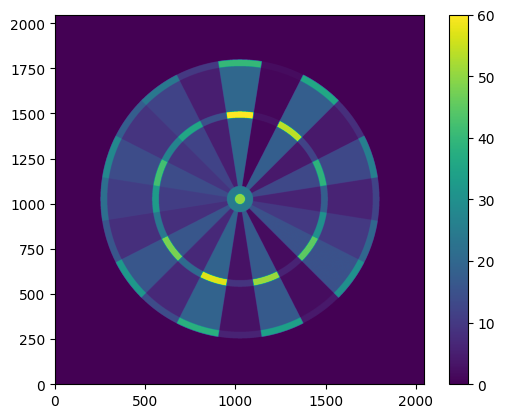

In [4]:
plt.imshow(board, origin='lower')
plt.colorbar()

In [5]:
mu = np.array([0, 0])
Sigma = np.array([[10, 0], [0, 10]])

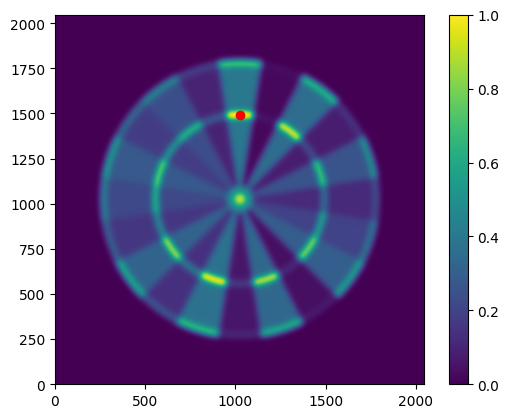

In [6]:
exp = expected_score(board, mu, Sigma, padding=100)
i, j = np.unravel_index(np.argmax(exp), board.shape)
plt.imshow(exp, origin='lower')
plt.scatter(j, i, color='red')
plt.colorbar()

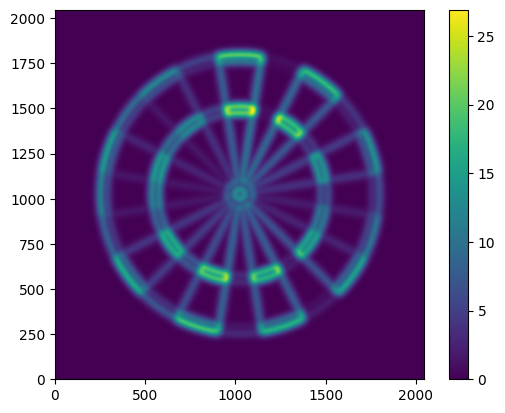

In [7]:
plt.imshow(std_score(board, mu, Sigma, padding=100), origin='lower')
plt.colorbar()

In [122]:
mu = np.array([0, 0])
Sigma = np.array([[1, 0], [0, 1]])

x_coords = []
y_coords = []
maxes = []
stds = []
for sigma in tqdm(np.linspace(0.01, 50, 50)):
    exp = expected_score(board, mu, sigma*sigma*Sigma, padding=200)
    std = std_score(board, mu, sigma*sigma*Sigma, padding=200)
    
    i, j = np.unravel_index(exp.argmax(), exp.shape)
    
    maxes.append(np.max(exp))
    x_coords.append(j)
    y_coords.append(i)
    stds.append(std[i, j])

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:25<00:00,  4.11s/it]


In [123]:
df = pd.DataFrame(list(zip(np.linspace(0.01, 50, 50), maxes, x_coords, y_coords, stds)), 
                  columns=['sigma', 'max_score', 'x', 'y', 'std']).set_index('sigma')

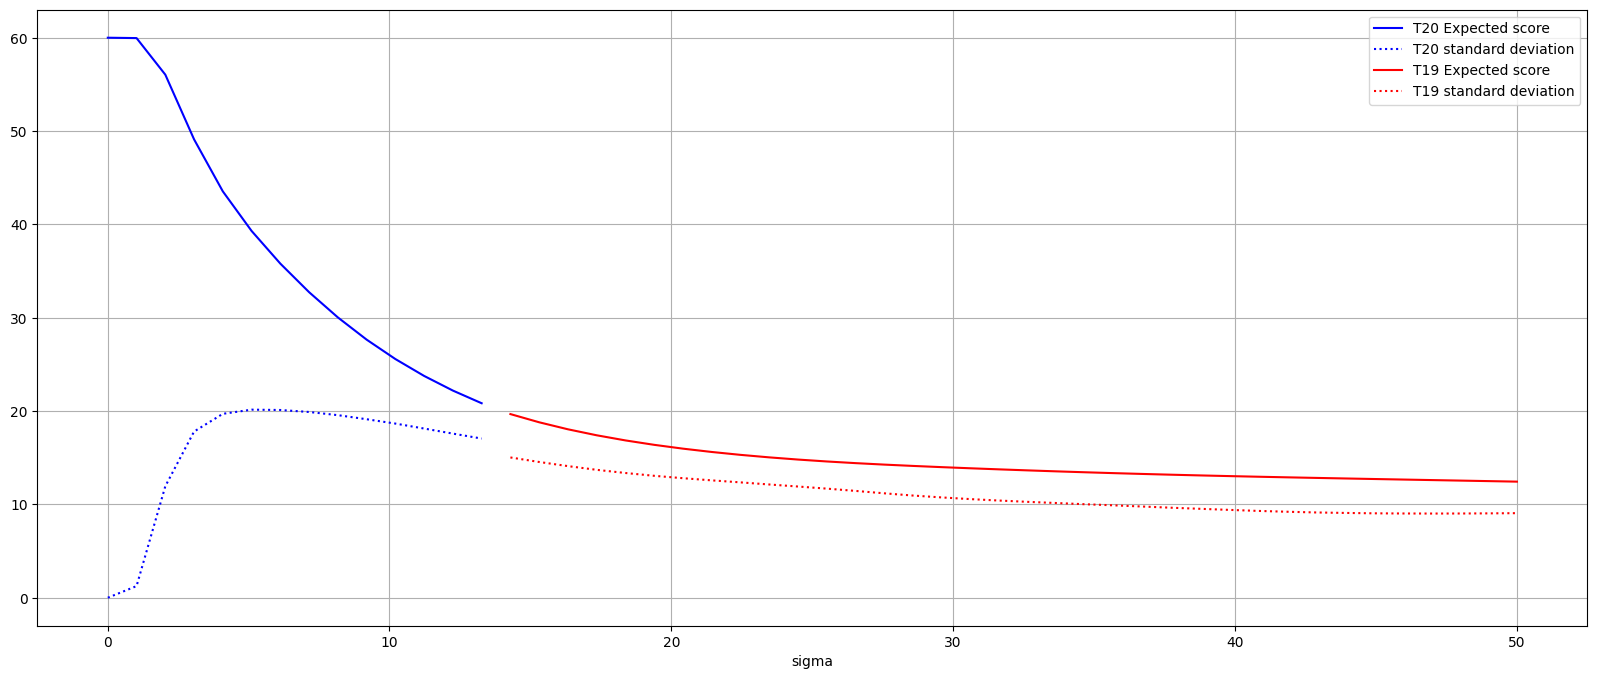

In [124]:
fig, ax = plt.subplots(1, figsize=(20, 8))
df[df.y > 1200].max_score.plot(c='b', ax=ax, label='T20 Expected score')
df[df.y > 1200]['std'].plot(c='b', style=':', ax=ax, label='T20 standard deviation')
df[df.y < 1200].max_score.plot(c='r', ax=ax, label='T19 Expected score')
df[df.y < 1200]['std'].plot(c='r', style=':', ax=ax, label='T19 standard deviation')
ax.grid()
ax.legend()

In [125]:
from scipy.signal import convolve2d

In [126]:
c = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
c = c != 0

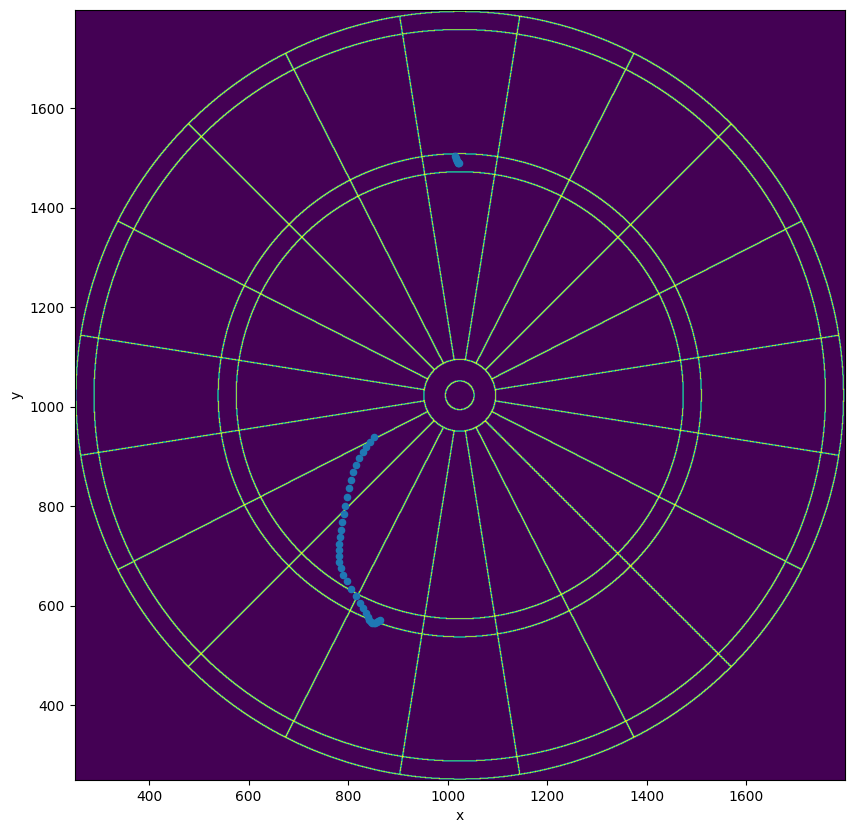

In [127]:
df[df.index>5].plot.scatter('x', 'y', figsize=(10, 10))
margin = 250
plt.ylim(margin, board.shape[1]-margin)
plt.xlim(margin, board.shape[0]-margin)
plt.imshow(c)

## Quadro

In [8]:
quadro = generate_dartboard(2048, quadro=True)

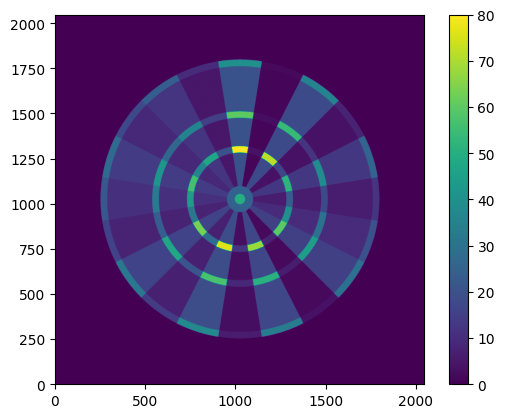

In [9]:
plt.imshow(quadro, origin='lower')
plt.colorbar()

In [36]:
from tqdm import tqdm

In [37]:
for i in tqdm(range(15), position=0):
    [n**4 for n in range(1000000)]

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:05<00:00,  2.62it/s]


In [38]:
mu = np.array([0, 0])
Sigma = np.array([[1, 0], [0, 1]])

x_coords = []
y_coords = []
maxes = []
stds = []
for sigma in tqdm(np.linspace(0.01, 80, 200), position=0):
    exp = expected_score(quadro, mu, sigma*sigma*Sigma, padding=200)
    std = std_score(quadro, mu, sigma*sigma*Sigma, padding=200)
    
    i, j = np.unravel_index(exp.argmax(), exp.shape)
    
    maxes.append(np.max(exp))
    x_coords.append(j)
    y_coords.append(i)
    stds.append(std[i, j])

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [18:04<00:00,  5.42s/it]


In [54]:
quadro_df = pd.DataFrame(list(zip(np.linspace(0.01, 80, 200), maxes, x_coords, y_coords, stds)), 
                  columns=['sigma', 'max_score', 'x', 'y', 'std']).set_index('sigma')

In [87]:
from matplotlib.colors import TABLEAU_COLORS 

In [100]:
quadro_df['group'] = (quadro_df.board_score.diff() != 0).cumsum()

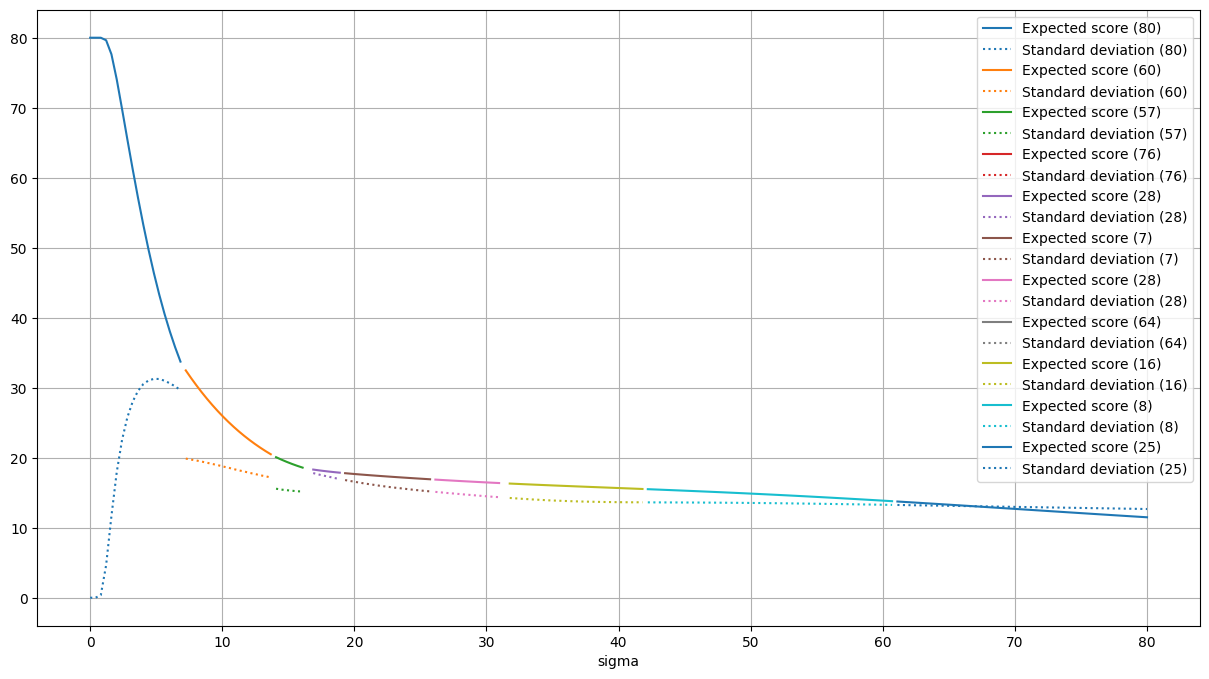

In [111]:
fig, ax = plt.subplots(1, figsize=(15, 8))
for group in quadro_df.group.unique():
    color = list(TABLEAU_COLORS.values())[(group-1 )% 10]
    df = quadro_df[quadro_df.group == group]
    df.max_score.plot(c=color, ax=ax, label=f'Expected score ({int(df.board_score.iloc[0])})')
    df['std'].plot(c=color, style=':', ax=ax, label=f'Standard deviation ({int(df.board_score.iloc[0])})')
ax.grid()
ax.legend()

In [56]:
from scipy.signal import convolve2d

In [57]:
q = convolve2d(quadro, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
q = q != 0

In [58]:
quadro_df['board_score'] = quadro_df[['x', 'y']].apply(lambda row: quadro[row.y, row.x], axis=1)

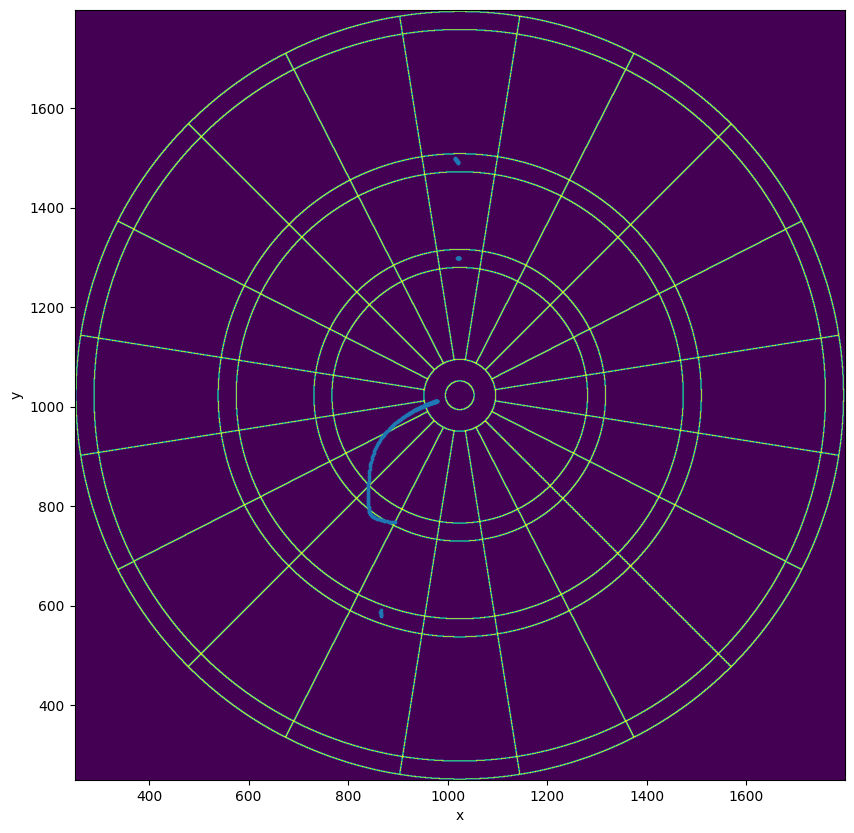

In [118]:
quadro_df[quadro_df.index > 2].plot.scatter('x', 'y', figsize=(10, 10), s=3)
margin = 250
plt.ylim(margin, quadro.shape[1]-margin)
plt.xlim(margin, quadro.shape[0]-margin)
plt.imshow(q)

## Play a game

In [62]:
from darts.game import Leg

In [63]:
leg = Leg(players=['Mikey', 'Sian'])

In [64]:
leg

Mikey:   501
 Sian:   501

In [65]:
leg.turn('Mikey', ['20', 'D7', '2'])

In [66]:
leg

Mikey:   501  465
 Sian:   501

## Aiming for a particular score

Goal: Suppose I have a particular throwing distribution, with variance matrix $\Sigma$. I want to score exactly $N$ points on the next throw, by hitting a specific segment of the board (including doubles/triples/bulls). For each segment, which point should I aim for to maximise the probability of getting the right score?

In [128]:
board

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [129]:
i, j = 100, 100

In [130]:
from darts.stats import gaussian_filter

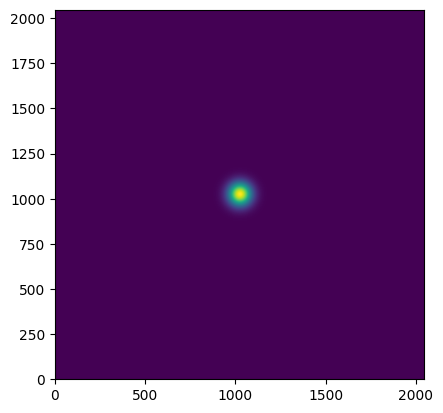

In [138]:
plt.imshow(gaussian_filter(board, (0, 0), 100*Sigma), origin='lower')

In [288]:
gf = gaussian_filter(board, (0, 0), 100*Sigma)
gf = gf / np.sum(gf)

In [289]:
sum(sum(np.where(board == 25, gf, 0)))

0.5348848794092322

In [340]:
from skimage.feature import peak_local_max

In [345]:
allowed_scores = [1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34,
        36, 38, 39, 40, 42, 45, 48, 50, 51, 54, 57, 60]

In [346]:
probs = {}
for allowed_score in tqdm(allowed_scores):
    indicator = np.where(board == allowed_score, 1, 0)
    board_ft = np.fft.fft2(indicator)
    filter_ft = np.fft.fft2(np.fft.ifftshift(gf))
    prod_ft = board_ft * filter_ft
    acc = np.real(np.fft.ifft2(prod_ft))
    xy = peak_local_max(acc, min_distance=2, threshold_abs=1e-10)
    for i, j in xy:
        probs[(i, j)] = acc[i, j]

100%|██████████████████████████████████████████████████████████████████████████████████| 43/43 [01:08<00:00,  1.60s/it]


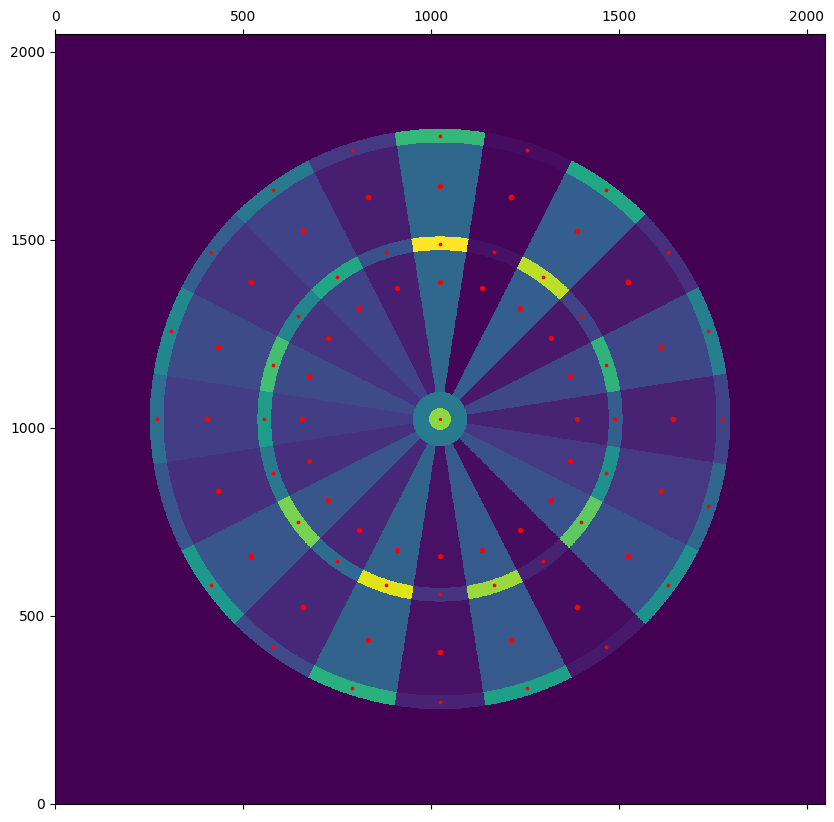

In [349]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(board, origin='lower')
for (i, j), p in probs.items():
    ax.scatter(j, i, color='red', s=10*p)

## Strategy

Suppose I have the score $N$, and want to check out in the next $D$ darts. Assuming I am at the points in each segment described in the previous section, where should I aim? 

https://www.tandfonline.com/doi/abs/10.1080/01605682.2019.1610341

https://arxiv.org/pdf/2011.11031.pdf